In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pl = pd.read_excel(r"C:\Users\aser\OneDrive\Рабочий стол\DATASETS\Apple.xlsx", sheet_name='P&L', parse_dates=[0])
bl = pd.read_excel(r"C:\Users\aser\OneDrive\Рабочий стол\DATASETS\Apple.xlsx", sheet_name='Balance', parse_dates=[0])
cfs = pd.read_excel(r"C:\Users\aser\OneDrive\Рабочий стол\DATASETS\Apple.xlsx", sheet_name='Cash Flow', parse_dates=[0])
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
pl.columns = pl.columns.str.lower()
bl['date'] = pd.to_datetime(bl['date'], format = "%Y.%d.%m")
pl['date'] = pl['date'].dt.year
bl['date'] = bl['date'].dt.year
cfs['date'] = cfs['date'].dt.year
cfs.columns
cfs = cfs.rename(columns={"operating cash flow": "ocf", " net equity repurchased": "nqr"})
cfs['dividends'] = np.where(cfs['dividends'] == 'None', 0, cfs['dividends'])

In [3]:
pl['revenue_growth'] = '0' #We need empty column for the next command to work 
for i, n in enumerate(pl['revenue']):
    if i < (len(pl['revenue'])-1):
        pl['revenue_growth'][i] = (pl['revenue'][i]/ pl['revenue'][i+1]-1)*100
    else:
        pl['revenue_growth'][i] = '0'

pl['revenue_growth'] = round(pl['revenue_growth'].astype('float64'), 2)
CAGR = (pl['revenue'][0] / pl['revenue'].iloc[-1]) ** (1/(len(pl['revenue']) -1)) - 1
pl['gross_margin'] = round(pl['gross profit'] / pl['revenue'] * 100, 2)
pl['operating_margin'] = round(pl['operating income'] / pl['revenue'] * 100, 2)
pl['net_margin'] = round(pl['net income'] / pl['revenue'] * 100, 2)
net_debt = bl['long-term debt'] - bl['cash on hand']
nd_op_in = net_debt / pl['operating income']
cfs['fcf'] = cfs['ocf'] - cfs['capex']
cfs['payout_ratio'] = (cfs['dividends'] + cfs['nqr']) / cfs['fcf'] * 100
cfs[cfs['date'] >= 2013]['payout_ratio'].mean() #For the past 10 years, Apple has payed 100% of its FCF

<ipython-input-3-707e4d21f5e8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pl['revenue_growth'][i] = (pl['revenue'][i]/ pl['revenue'][i+1]-1)*100
<ipython-input-3-707e4d21f5e8>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pl['revenue_growth'][i] = '0'


100.56941074016791

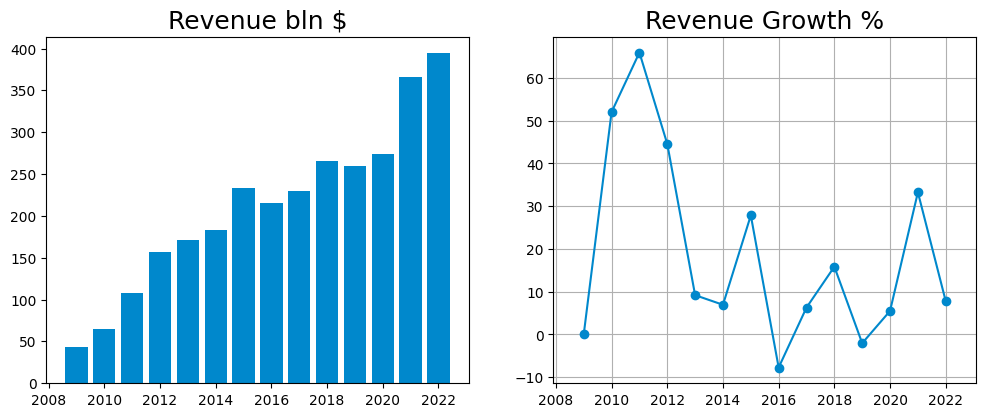

In [4]:
revenue_graph, axs = plt.subplots(1,2, figsize = (12,4.5), sharex=True)
axs[0].bar(pl['date'], pl['revenue']/1000, color ='#0088cc')
axs[0].set_title('Revenue bln $', fontsize=18)
axs[1].plot(pl['date'], pl['revenue_growth'], color ='#0088cc', marker='o')
axs[1].set_title('Revenue Growth %', fontsize=18)
axs[1].grid(True)